# No Derivation, No Relation — Closure Certificate on natural `located_in`

**Demo of:** *Closure certificate vs a confidence battery vs a query-side false-premise verifier on natural located-in* (iter-8 domain-generality experiment).

This artifact adapts a neuro-symbolic "no-derivation, no-relation" **closure certificate** to a
second genuinely-natural absent-relation domain: **Re-DocRED geographic / administrative
containment** (`located_in` / `contains`). An LLM extracts atomic containment edges from natural
Wikipedia prose; a tiny symbolic engine then runs a **forward least-fixpoint UNION closure** over a
*degenerate* transitive table

```
located_in ∘ located_in = located_in        contains ∘ contains = contains
located_in ∘ contains   = UNDEFINED          contains ∘ located_in = UNDEFINED
```

and **emits a relation only when it is uniquely derivable**. With no derivation it **abstains** — so
it can never invent a containment between two *sibling* places (both inside the same parent), where
`located_in ∘ contains` is UNDEFINED. That is a **genuine deductive abstention**, not a guess.

**What this demo shows (no LLM calls — it replays cached reads):**

1. The symbolic **closure engine** (`kinship.py`, reused *verbatim*), parameterized by the
   degenerate `located_in`/`contains` table, with the GATE-0 wiring checks.
2. **Worked traces**: a present 2-hop `located_in` composition (covered) and a sibling pair where
   the raw LLM confidently commits a containment but the certificate **abstains by deduction**.
3. The headline evidence recomputed from cached per-query predictions:
   - **FACT A** — raw LLM confidently hallucinates a containment on ~30% of natural *sibling*
     absent pairs (vs ~6% for disconnected places).
   - **FACT B** — the certificate catches ~78% of those high-confidence hallucinations
     *structurally*, beating every dispersion signal and the query-side verifier.

> The full run is 1,215 queries / 283 docs. This demo recomputes on a balanced **~95-row subset**,
> so demo numbers *approximate* (not equal) the published full-run reference, which is shown
> alongside for comparison.

In [1]:
# --- Dependencies (Colab-safe install pattern) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab; install locally to match Colab's versions.
# (On Colab, pip-installing these would corrupt the pre-loaded C extensions, so they are
#  behind the google.colab guard.)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports ---
# Original engine imports (from kinship.py), plus numpy/matplotlib for the demo.
from __future__ import annotations
from collections import defaultdict, deque
from typing import Iterable
import json, os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- Data loading (GitHub URL with local fallback, Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-8/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("top-level keys:", list(data.keys()))
print("n examples:", len(data["examples"]))
print("composition_table relation types:", list(data["composition_table"]["relation_types"].keys()))

top-level keys: ['composition_table', 'examples', 'worked_traces', 'headline_reference']
n examples: 95
composition_table relation types: ['located_in', 'contains']


## Configuration

All tunable knobs live here. The competitor sets mirror the constants in the original `method.py`.
`MAX_PER_GROUP` subsamples the loaded examples per regime — set small to smoke-test, or `None` to
use the full demo subset (~95 rows). The whole pipeline is pure-Python and runs in well under a
second, so the "full" demo subset is the default.

In [5]:
# Competitor sets (verbatim from method.py)
SIGNALS    = ("verbalized", "sc_margin", "ptrue", "negent")   # 4 dispersion confidence signals
QUERYSIDE  = ("queryside_verifier", "queryside_selfverify")   # 2 query-side false-premise baselines
BASELINES6 = tuple(f"ct_{s}" for s in SIGNALS) + QUERYSIDE     # 6 confident-wrong competitors

# Demo scale: examples processed per regime group. Start tiny, scale up.
# MAX_PER_GROUP = 5      # absolute-minimum smoke value
MAX_PER_GROUP = None     # None = use the whole ~95-row demo subset (runs in <1s)

SEED = 20260618          # mirrors method.py

## 1. The symbolic closure engine (`kinship.py`, reused verbatim)

The engine is a **finite-composition forward least-fixpoint UNION closure**. It is the *same* engine
used for the CLUTRR kinship calculus — here it is parameterized entirely by the degenerate
`located_in` / `contains` transitive table from the dataset (no code changes).

For a directed pair `a→b` it accumulates **every** relation type derivable by composing atomic
edges. The output contract is hallucination-safe by construction:

| `|D[query]|` | meaning | decision |
|---|---|---|
| `1` | unique derivation | **emit** the relation (covered) |
| `0` | no connecting path | **ABSTAIN** (absent / underdetermined) |
| `>1` | incompatible derivations | **ABSTAIN** (conflict) |

The code below is copied verbatim from the artifact's `kinship.py`.

In [6]:
# ============================ kinship.py (verbatim) ============================
class Kinship:
    """Finite kinship composition calculus parsed from the dataset composition table."""

    def __init__(self, comp_table: dict):
        rt = comp_table["relation_types"]
        self.base: list[str] = list(rt.keys())  # 11 abstract relation types
        self.universe = frozenset(self.base)
        self.empty = frozenset()
        self.symmetric_types = set(comp_table["symmetric_types"])  # {'sibling','SO'}
        self.inv: dict[str, str] = {}
        for a, b in comp_table["inverse_pairs"].items():
            self.inv[a] = b
            self.inv[b] = a
        self.composition_rules = comp_table["composition_rules"]
        self.surface_forms = comp_table["surface_forms"]
        self.surface_reverse = comp_table["surface_reverse"]
        self.label_map = comp_table.get("label_map", {})
        self.label_map_reverse = comp_table.get("label_map_reverse", {})
        # ---- total converse over every base type (sound; no empties) ----
        self._conv: dict[str, str] = {}
        for t in self.base:
            if t in self.symmetric_types:
                self._conv[t] = t
            elif t in self.inv:
                self._conv[t] = self.inv[t]
            elif t == "sibling-in-law":
                self._conv[t] = t
            else:
                self._conv[t] = t  # sound self-converse fallback

    def conv_type(self, t: str) -> str:
        return self._conv[t]

    def compose_types(self, t1: str, t2: str):
        """Defined composition rules[t1][t2]=t3, else None (UNDEFINED == 'unknown')."""
        return self.composition_rules.get(t1, {}).get(t2)

    def label(self, s) -> str:
        s = frozenset(s)
        if not s:
            return "EMPTY"
        if s == self.universe:
            return "UNIVERSE"
        return "|".join(t for t in self.base if t in s)

    def surface(self, rel_type: str, gender: str) -> str:
        g = "male" if str(gender).lower().startswith("m") else "female"
        sf = self.surface_forms.get(rel_type)
        if not sf:
            return rel_type
        return sf.get(g, sf.get("male", rel_type))

    def surface_to_type(self, surface_word: str):
        """Return (relation_type, implied_gender) or None for an unknown word."""
        w = str(surface_word).strip().lower()
        rev = self.surface_reverse.get(w)
        if rev is None:
            return None
        return rev[0], rev[1]


def _seed(kin: Kinship, atomic_edges: list[dict]):
    """Seed D with atomic edges + their converses. Returns (D, nbrs)."""
    D: dict = defaultdict(set)
    nbrs: dict = defaultdict(set)

    def add(a, b, t):
        if t not in D[(a, b)]:
            D[(a, b)].add(t)
            nbrs[a].add(b)

    for e in atomic_edges:
        t = e["type"]
        if t not in kin.base:
            continue
        a, b = e["a"], e["b"]
        if a == b:
            continue
        add(a, b, t)
        add(b, a, kin.conv_type(t))
    return D, nbrs


def forward_closure(kin: Kinship, atomic_edges: list[dict], with_prov: bool = False):
    """Forward least-fixpoint union derivation (the sound closure for the finite table)."""
    D, nbrs = _seed(kin, atomic_edges)
    prov: dict = {}
    if with_prov:
        for (a, b), ts in D.items():
            for t in ts:
                prov.setdefault((a, b, t), None)
    Q = deque(D.keys())
    inq = set(D.keys())
    n_fired = 0

    def push(p):
        if p not in inq:
            inq.add(p)
            Q.append(p)

    def emit(a, c, t3, provtuple):
        nonlocal n_fired
        grew = False
        if t3 not in D[(a, c)]:
            D[(a, c)].add(t3)
            nbrs[a].add(c)
            if with_prov:
                prov.setdefault((a, c, t3), provtuple)
            n_fired += 1
            grew = True
        ct3 = kin.conv_type(t3)
        if ct3 not in D[(c, a)]:
            D[(c, a)].add(ct3)
            nbrs[c].add(a)
            if with_prov:
                prov.setdefault((c, a, ct3), (c, a, a, ct3, None, ct3))  # converse marker
        if grew:
            push((a, c)); push((c, a))

    while Q:
        (a, b) = Q.popleft()
        inq.discard((a, b))
        tab = list(D[(a, b)])
        # extend a->b with b->c  =>  a->c
        for c in list(nbrs[b]):
            if c == a:
                continue
            for t1 in tab:
                for t2 in list(D[(b, c)]):
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(a, c, t3, (a, b, c, t1, t2, t3))
        # extend z->a with a->b  =>  z->b   (a is the middle)
        for z in list(nbrs[a]):
            if z == b:
                continue
            for t1 in list(D[(z, a)]):
                for t2 in tab:
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(z, b, t3, (z, a, b, t1, t2, t3))
    if with_prov:
        return D, nbrs, n_fired, prov
    return D, nbrs, n_fired


def _answer_from_set(kin: Kinship, R: set) -> dict:
    R = set(R)
    n = len(R)
    if n == 1:
        t = next(iter(R))
        return {"types": sorted(R), "singleton": True, "answer_type": t,
                "n_derivations": n, "mode_b_conflict": False, "no_path": False}
    if n == 0:
        return {"types": [], "singleton": False, "answer_type": None,
                "n_derivations": 0, "mode_b_conflict": False, "no_path": True}
    # n > 1 : incompatible derivations => Mode-B conflict
    rep = sorted(R, key=lambda t: kin.base.index(t))[0]
    return {"types": sorted(R), "singleton": False, "answer_type": rep,
            "n_derivations": n, "mode_b_conflict": True, "no_path": False}


def query_modeA(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt) -> dict:
    """Mode-A forward-closure query. Returns the output-contract decision + n_fired."""
    D, nbrs, n_fired = forward_closure(kin, atomic_edges)
    R = D.get((qsrc, qtgt), set())
    out = _answer_from_set(kin, R)
    out["n_fired"] = n_fired
    return out


def derivation_trace(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt, max_steps: int = 60):
    """Reconstruct ONE concrete derivation for (qsrc->qtgt) for the trace-graph."""
    D, nbrs, _, prov = forward_closure(kin, atomic_edges, with_prov=True)
    target = D.get((qsrc, qtgt), set())
    if len(target) != 1:
        return []
    goal_type = next(iter(target))
    steps = []
    stack = [(qsrc, qtgt, goal_type)]
    seen = set()
    while stack and len(steps) < max_steps:
        key = stack.pop()
        if key in seen:
            continue
        seen.add(key)
        p = prov.get(key)
        if p is None:
            continue  # seed edge (atomic fact) -- a leaf of the proof DAG
        a, b, c, t1, t2, t3 = p
        if t2 is None:
            stack.append((c, a, kin.conv_type(t3)))
            continue
        steps.append({"a": a, "b": b, "c": c, "t1": t1, "t2": t2, "t3": t3})
        stack.append((a, b, t1))
        stack.append((b, c, t2))
    steps.reverse()
    return steps
# ============================ end kinship.py ============================

kin = Kinship(data["composition_table"])
print("relation types (base):", kin.base)
print("converse(located_in)  :", kin.conv_type("located_in"))

relation types (base): ['located_in', 'contains']
converse(located_in)  : contains


### GATE-0: engine wiring checks (no LLM)

These mirror the artifact's `tests.py` — they assert the degenerate table is loaded correctly. The
two **UNDEFINED** compositions (`located_in ∘ contains`, `contains ∘ located_in`) are exactly why
the certificate abstains on sibling places.

In [7]:
# GATE-0 (no-LLM) engine sanity, from tests.py / method.py main()
assert kin.base == ["located_in", "contains"], kin.base
assert kin.compose_types("located_in", "located_in") == "located_in"
assert kin.compose_types("contains", "contains") == "contains"
assert kin.compose_types("located_in", "contains") is None     # UNDEFINED -> sound abstain
assert kin.compose_types("contains", "located_in") is None     # UNDEFINED -> sound abstain
assert kin.conv_type("located_in") == "contains"
assert kin.conv_type("contains") == "located_in"
assert kin.surface("located_in", "male") == "located in"
assert kin.surface_to_type("located in") == ("located_in", "male")
print("[OK] degenerate located_in/contains table wired correctly")
print("     located_in o located_in =", kin.compose_types("located_in", "located_in"))
print("     located_in o contains   =", kin.compose_types("located_in", "contains"), "(UNDEFINED -> abstain)")

[OK] degenerate located_in/contains table wired correctly
     located_in o located_in = located_in
     located_in o contains   = None (UNDEFINED -> abstain)


## 2. Worked traces

### 2a. The mechanism, on a tiny synthetic graph

Two illustrative cases over place edges (`a located_in b`). The engine treats node labels as opaque,
so we can use place names directly.

- **Present (2-hop composition):** `Brooklyn → NYC → New York State` ⟹ `located_in ∘ located_in =
  located_in` — a unique derivation, so the certificate **emits** `located_in`.
- **Sibling (no derivation):** `Brooklyn → NYC` and `Queens → NYC`. To answer `Brooklyn → Queens`
  the only path is `Brooklyn located_in NYC`, then `NYC contains Queens` (converse) — i.e.
  `located_in ∘ contains`, which is **UNDEFINED**. Closure is EMPTY ⟹ the certificate **ABSTAINS**.

In [8]:
# 2a. synthetic mechanism demo (mirrors the kinship.py __main__ self-test)
present_edges = [{"a": "Brooklyn", "b": "NYC", "type": "located_in"},
                 {"a": "NYC", "b": "New York State", "type": "located_in"}]
sibling_edges = [{"a": "Brooklyn", "b": "NYC", "type": "located_in"},
                 {"a": "Queens",   "b": "NYC", "type": "located_in"}]

a1 = query_modeA(kin, present_edges, "Brooklyn", "New York State")
print("PRESENT  Brooklyn -> New York State :", "EMIT " + a1["answer_type"] if a1["singleton"]
      else "ABSTAIN", "| n_fired =", a1["n_fired"])
print("         derivation trace:", derivation_trace(kin, present_edges, "Brooklyn", "New York State"))

a2 = query_modeA(kin, sibling_edges, "Brooklyn", "Queens")
print("SIBLING  Brooklyn -> Queens        :", "EMIT " + str(a2["answer_type"]) if a2["singleton"]
      else "ABSTAIN (no derivation: located_in o contains is UNDEFINED)")

PRESENT  Brooklyn -> New York State : EMIT located_in | n_fired = 1
         derivation trace: [{'a': 'Brooklyn', 'b': 'NYC', 'c': 'New York State', 't1': 'located_in', 't2': 'located_in', 't3': 'located_in'}]
SIBLING  Brooklyn -> Queens        : ABSTAIN (no derivation: located_in o contains is UNDEFINED)


### 2b. Real worked traces from the run

The same engine on the **actual extracted edges** of two natural Re-DocRED documents (the LLM reads
are cached in the data). The sibling case is the decisive one: the raw LLM commits a containment at
high confidence, while the certificate abstains by deduction.

In [9]:
# 2b. real worked traces (LLM-extracted edges replayed from cache)
def run_trace(trace, qsrc_key="qsrc_name", qtgt_key="qtgt_name"):
    edges = [{"a": e["a"], "b": e["b"], "type": e["type"]} for e in trace["extracted_atomics"]]
    qsrc, qtgt = trace[qsrc_key], trace[qtgt_key]
    # the engine queries by the entity labels that appear in the extracted edges; fall back to names
    a = query_modeA(kin, edges, qsrc, qtgt)
    return edges, a

pc = data["worked_traces"]["present_composition"]
print("=== PRESENT composition trace ===")
print("doc:", pc["title"], "| Q:", pc["question"])
print("extracted located_in edges:")
for e in pc["extracted_atomics"]:
    print("   ", e["a"], "-located_in->", e["b"])
print("gold:", pc["gold_word"], "| certificate:", pc["certificate_word"],
      "(unique derivation via located_in o located_in = located_in)")

print()
nd = data["worked_traces"]["sibling_no_derivation"]
edges_nd, a_nd = run_trace(nd)
print("=== SIBLING no-derivation trace (DECISIVE) ===")
print("doc:", nd["title"], "| Q:", nd["question"])
print("extracted located_in edges:")
for e in nd["extracted_atomics"]:
    print("   ", e["a"], "-located_in->", e["b"])
print("gold:", nd["gold"])
print("raw LLM committed:", nd["raw_llm_committed"], "(high confidence)")
live = "EMIT " + str(a_nd["answer_type"]) if a_nd["singleton"] else "ABSTAIN (no_path)"
print("LIVE engine on extracted edges:", live, "<- forward closure is EMPTY")
print("certificate decision (cached):", nd["certificate_decision"])

=== PRESENT composition trace ===
doc: Algarrobo, Spain | Q: What is the geographic relationship of Algarrobo Costa to Andalusia?
extracted located_in edges:
    Algarrobo -located_in-> Málaga
    Málaga -located_in-> Andalusia
    Algarrobo -located_in-> La Axarquía
    Algarrobo -located_in-> Algarrobo Costa
    Algarrobo -located_in-> Mezquitilla
    Algarrobo -located_in-> Trayamar
gold: located in | certificate: located in (unique derivation via located_in o located_in = located_in)

=== SIBLING no-derivation trace (DECISIVE) ===
doc: A Sầu Valley | Q: What is the geographic relationship of thung lũng A Sầu to Route 548?
extracted located_in edges:
    thung lũng A Sầu -located_in-> Thừa Thiên-Huế Province
    Thừa Thiên-Huế Province -located_in-> Vietnam
gold: no-relation
raw LLM committed: contains (high confidence)
LIVE engine on extracted edges: ABSTAIN (no_path) <- forward closure is EMPTY
certificate decision (cached): ABSTAIN (no-relation)


## 3. Recompute the headline evidence from cached predictions

Every per-query row carries the cached decisions of all methods — the certificate, the raw LLM
commit, the four dispersion-signal confidence baselines, and the two query-side baselines — plus the
gold label. We reconstruct the minimal record each scoring function expects and then run the
artifact's scoring helpers (`fact_a`, `natural_cw`) and the crux fraction-caught rule **verbatim**.

Scoring primitives (`coverage_confidence`, `confident_wrong`, `matched_coverage_mask`) are copied
verbatim from `baselines.py` / `stats.py`.

In [10]:
# --- scoring primitives (verbatim: baselines.py / stats.py) ---
def coverage_confidence(named: bool, conf: float) -> float:
    """An abstention is never 'covered' -> coverage-confidence -1 (below any real [0,1] conf)."""
    return float(conf) if named else -1.0

def confident_wrong(named: bool, surface, gold_surface: str, is_absent: bool) -> bool:
    """A named answer that disagrees with gold (for absent, ANY named answer is wrong)."""
    if not named:
        return False
    if is_absent:
        return True
    return surface != gold_surface

def matched_coverage_mask(conf: np.ndarray, target_cov: float) -> np.ndarray:
    """Boolean mask covering the top ceil(target_cov * N) items by confidence (ties by index)."""
    n = len(conf)
    k = int(round(target_cov * n)); k = max(0, min(n, k))
    mask = np.zeros(n, dtype=bool)
    if k == 0:
        return mask
    order = sorted(range(n), key=lambda i: (-conf[i], i))
    for i in order[:k]:
        mask[i] = True
    return mask

def _r(x, nd=4):
    return round(float(x), nd) if isinstance(x, (int, float)) else x

# --- reconstruct the internal record from a cached output row ---
# A method 'names' a relation iff its prediction is not the ABSTAIN sentinel.
def row_to_record(row):
    raw_named = bool(row["metadata_raw_named"])
    is_absent = bool(row["metadata_is_absent"])
    named = lambda f: row[f] != "ABSTAIN"
    sig = {"verbalized": float(row.get("metadata_conf_verbalized") or 0.0),
           "sc_margin":  float(row.get("metadata_conf_sc_margin") or 0.0),
           "ptrue":      float(row.get("metadata_conf_ptrue") or 0.0),
           "negent":     float(row.get("metadata_conf_negent") or 0.0)}
    raw_surface = row["predict_commit_argmax"] if raw_named else None
    r = {"is_absent": is_absent,
         "absent_regime": (row["metadata_regime"] if is_absent else None),
         "gold_surface": row["output"], "_sig": sig,
         "raw": {"named": raw_named, "conf": sig["verbalized"], "surface": raw_surface},
         "modeA": {"named": named("predict_certificate"),
                   "surface": (row["predict_certificate"] if named("predict_certificate") else None)},
         "commit_argmax": {"named": named("predict_commit_argmax")},
         "queryside_verifier":  {"named": named("predict_queryside_verifier")},
         "queryside_selfverify": {"named": named("predict_queryside_selfverify")}}
    for s in SIGNALS:  # confidence-threshold baselines mirror raw's named decision; conf = signal value
        r[f"ct_{s}"] = {"named": raw_named, "conf": sig[s], "surface": raw_surface}
    return r

# apply MAX_PER_GROUP subsampling, then reconstruct
def _group(e):
    if not e["metadata_is_absent"]:
        return "present"
    return "sibling" if e["metadata_regime"] == "same_component_sibling" else "diff"

by_group = defaultdict(list)
for e in data["examples"]:
    by_group[_group(e)].append(e)
rows = []
for g, lst in by_group.items():
    rows.extend(lst if MAX_PER_GROUP is None else lst[:MAX_PER_GROUP])

records = [row_to_record(e) for e in rows]
present = [r for r in records if not r["is_absent"]]
sib     = [r for r in records if r.get("absent_regime") == "same_component_sibling"]
diff    = [r for r in records if r.get("absent_regime") == "different_component"]
print(f"records: present={len(present)}  sibling-absent={len(sib)}  diffcomponent-absent={len(diff)}")

records: present=20  sibling-absent=60  diffcomponent-absent=15


### FACT A — raw LLM hallucination rate per absent regime

`fact_a` (verbatim from `method.py`): on an absent pool, the fraction of pairs where the raw LLM
**named** a containment (every named answer is wrong, since gold is `no-relation`), plus the
confidence distribution of those fabrications. The **sibling** regime is the hard, decisive one;
**different_component** (disconnected places) is easy.

In [11]:
# fact_a -- verbatim from method.py
def fact_a(pool):
    if not pool:
        return {"n": 0, "rate": float("nan")}
    named = [r for r in pool if r["raw"]["named"]]
    rate = len(named) / len(pool)
    if named:
        confs = np.array([r["raw"]["conf"] for r in named], float)
        cdist = {"mean": _r(float(confs.mean())), "median": _r(float(np.median(confs))),
                 "frac_ge_0.7": _r(float(np.mean(confs >= 0.7))), "frac_ge_0.9": _r(float(np.mean(confs >= 0.9)))}
    else:
        cdist = {}
    return {"n": len(pool), "n_hallucinated": len(named), "rate": _r(rate),
            "hallucination_confidence_distribution": cdist}

factA = {"same_component_sibling": fact_a(sib), "different_component": fact_a(diff)}
ref_A = data["headline_reference"]["FACT_A_raw_llm_hallucination_rate_per_regime"]
print("FACT A  (raw LLM confidently fabricates a containment on an absent pair)")
print(f"  sibling        : demo rate = {factA['same_component_sibling']['rate']}"
      f"   (full-run ref = {ref_A['same_component_sibling']})")
print(f"  diff-component : demo rate = {factA['different_component']['rate']}"
      f"   (full-run ref = {ref_A['different_component']})")
print("  sibling hallucination confidence dist:", factA["same_component_sibling"].get("hallucination_confidence_distribution"))

FACT A  (raw LLM confidently fabricates a containment on an absent pair)
  sibling        : demo rate = 0.3167   (full-run ref = 0.3)
  diff-component : demo rate = 0.0667   (full-run ref = 0.06)
  sibling hallucination confidence dist: {'mean': 0.9421, 'median': 0.95, 'frac_ge_0.7': 1.0, 'frac_ge_0.9': 0.8947}


### FACT B — fraction of high-confidence hallucinations each method *catches*

On the decisive **mixed sibling pool** (present + sibling-absent), take the rows where the raw LLM is
confident-wrong (the hallucinations). For each competitor, what fraction does it turn into an
abstention?

- **certificate** — abstains structurally (no derivation).
- **query-side verifier / self-verify** — the gate flips to abstain.
- **dispersion signals** — a single global confidence threshold, calibrated to the certificate's
  mixed coverage (the crux rule from `method.py`'s `crux_survival_table`); `caught = 1 − survival`.

We also report each method's **natural confident-wrong rate** on the sibling pool (`natural_cw`,
verbatim) — the load-bearing comparison.

In [12]:
# natural_cw -- verbatim from method.py
def natural_cw(pool, method):
    if not pool:
        return float("nan")
    return float(np.mean([1.0 if r[method]["named"] else 0.0 for r in pool]))

# crux fraction-caught (mirrors method.py crux_survival_table, fraction_caught outputs only)
def crux_fraction_caught(records):
    absent = [r for r in records if r["is_absent"]]
    N, N_abs = len(records), len(absent)
    halluc = [r for r in absent if r["raw"]["named"]]
    n_h = len(halluc)
    cert_cov_mixed = float(np.mean([1.0 if r["modeA"]["named"] else 0.0 for r in records])) if N else float("nan")
    out = {"n_raw_confident_wrong": n_h, "certificate_coverage_mixed": _r(cert_cov_mixed),
           "fraction_caught": {}}
    # certificate: fraction of hallucinations it abstains on
    out["fraction_caught"]["certificate"] = _r(np.mean([0.0 if r["modeA"]["named"] else 1.0
                                                        for r in halluc])) if n_h else float("nan")
    # 4 dispersion signals: 1 - survival at tau calibrated to certificate mixed coverage
    for s in SIGNALS:
        m = f"ct_{s}"
        conf_mixed = np.array([coverage_confidence(r[m]["named"], r[m]["conf"]) for r in records], float)
        mask = matched_coverage_mask(conf_mixed, cert_cov_mixed) if (N and cert_cov_mixed == cert_cov_mixed) else np.zeros(N, bool)
        covered = sorted([conf_mixed[i] for i in range(N) if mask[i] and conf_mixed[i] >= 0.0])
        tau = covered[0] if covered else float("nan")
        vals = np.array([r["_sig"][s] for r in halluc], float) if n_h else np.array([])
        surv = float(np.mean(vals >= tau)) if (n_h and tau == tau) else float("nan")
        out["fraction_caught"][m] = _r(1.0 - surv) if surv == surv else float("nan")
    # 2 query-side baselines: caught == the gate abstains on the hallucination
    for m in QUERYSIDE:
        surv = float(np.mean([1.0 if r[m]["named"] else 0.0 for r in halluc])) if n_h else float("nan")
        out["fraction_caught"][m] = _r(1.0 - surv) if surv == surv else float("nan")
    return out

mixed_sibling = present + sib                      # the DECISIVE pool
crux = crux_fraction_caught(mixed_sibling)
fc = crux["fraction_caught"]
ref_B = data["headline_reference"]["FACT_B_crux_fraction_caught_per_baseline"]
ref_cw = data["headline_reference"]["LOAD_BEARING_natural_confident_wrong_on_sibling_absent"]

print(f"n high-confidence raw hallucinations in pool = {crux['n_raw_confident_wrong']}\n")
hdr = f"{'method':22s} {'caught(demo)':>13s} {'caught(ref)':>12s} {'cw_sib(demo)':>13s} {'cw_sib(ref)':>12s}"
print(hdr); print("-" * len(hdr))
order = ["certificate"] + list(BASELINES6)
cw_demo = {"certificate": natural_cw(sib, "modeA"), **{m: natural_cw(sib, m) for m in BASELINES6}}
for m in order:
    print(f"{m:22s} {fc.get(m, float('nan')):>13} {ref_B.get(m, float('nan')):>12} "
          f"{_r(cw_demo[m]):>13} {ref_cw.get(m, float('nan')):>12}")
print(f"\nraw commit natural confident-wrong on sibling pool: demo={_r(natural_cw(sib, 'commit_argmax'))}"
      f"  (ref={ref_cw.get('raw_commit')})")

n high-confidence raw hallucinations in pool = 19

method                  caught(demo)  caught(ref)  cw_sib(demo)  cw_sib(ref)
----------------------------------------------------------------------------
certificate                   0.9474       0.7852        0.0167       0.0733
ct_verbalized                 0.5263          0.4        0.3167          0.3
ct_sc_margin                  0.0526       0.0667        0.3167          0.3
ct_ptrue                      0.3158       0.3037        0.3167          0.3
ct_negent                     0.0526       0.0667        0.3167          0.3
queryside_verifier            0.3684       0.2741           0.2       0.2178
queryside_selfverify          0.5263       0.4593          0.15       0.1622

raw commit natural confident-wrong on sibling pool: demo=0.3167  (ref=0.3)


## 4. Summary & visualization

Bar charts of the two headline facts (demo subset vs published full-run reference) and a printed
verdict line. The certificate's structural "no-derivation, no-relation" abstention catches the
high-confidence hallucinations that confidence signals and the query-side verifier miss.

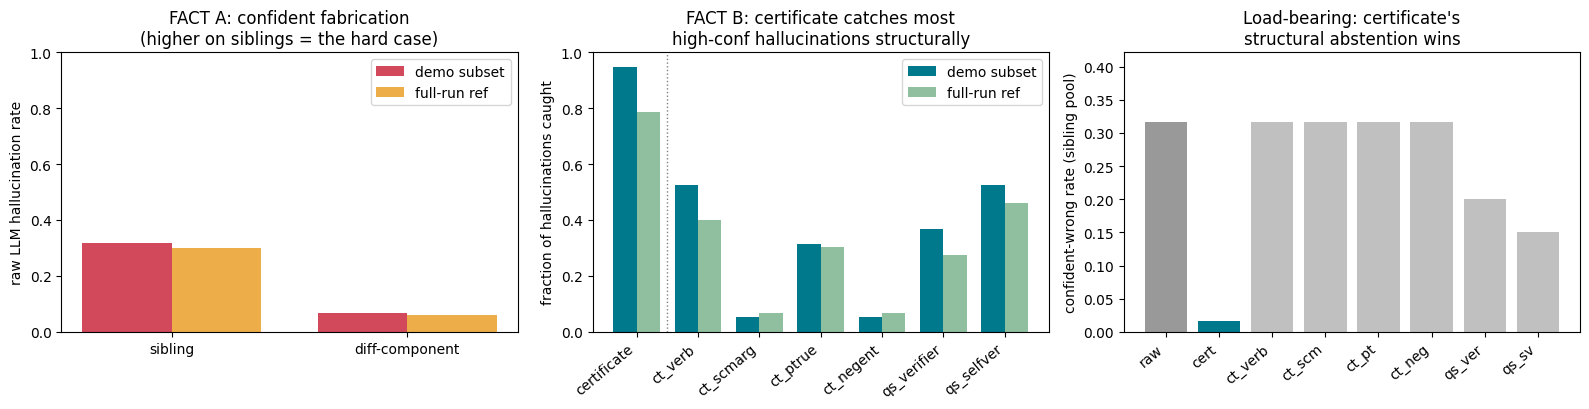

Gold-read engine ceiling (sound by construction): 1.0 present cov / 1.0 absent abstention
FORK verdict: EXTRACTION-LIMITED-BOUNDARY

On 450 NATURAL Wikipedia SAME-COMPONENT-SIBLING absent located-in pairs the raw LLM hallucinates a containment on 30% at high confidence; the certificate abstains by GENUINE DEDUCTION (located_in o contains UNDEFINED), confident-wrong 7%. The fork verdict is EXTRACTION-LIMITED-BOUNDARY.


In [13]:
# --- visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) FACT A per regime
ax = axes[0]
regs = ["sibling", "diff-component"]
demoA = [factA["same_component_sibling"]["rate"], factA["different_component"]["rate"]]
refA  = [ref_A["same_component_sibling"], ref_A["different_component"]]
x = np.arange(len(regs)); w = 0.38
ax.bar(x - w/2, demoA, w, label="demo subset", color="#d1495b")
ax.bar(x + w/2, refA, w, label="full-run ref", color="#edae49")
ax.set_xticks(x); ax.set_xticklabels(regs); ax.set_ylabel("raw LLM hallucination rate")
ax.set_title("FACT A: confident fabrication\n(higher on siblings = the hard case)")
ax.legend(); ax.set_ylim(0, 1)

# (2) FACT B fraction-caught
ax = axes[1]
labels = ["certificate"] + list(BASELINES6)
short = ["certificate", "ct_verb", "ct_scmarg", "ct_ptrue", "ct_negent", "qs_verifier", "qs_selfver"]
demoB = [fc.get(m, np.nan) for m in labels]
refB  = [ref_B.get(m, np.nan) for m in labels]
x = np.arange(len(labels))
ax.bar(x - w/2, demoB, w, label="demo subset", color="#00798c")
ax.bar(x + w/2, refB, w, label="full-run ref", color="#8fbf9f")
ax.set_xticks(x); ax.set_xticklabels(short, rotation=40, ha="right")
ax.set_ylabel("fraction of hallucinations caught")
ax.set_title("FACT B: certificate catches most\nhigh-conf hallucinations structurally")
ax.legend(); ax.set_ylim(0, 1)
ax.axvline(0.5, color="grey", ls=":", lw=1)

# (3) natural confident-wrong on sibling pool
ax = axes[2]
methods = ["raw_commit", "certificate"] + list(BASELINES6)
cwvals = [_r(natural_cw(sib, "commit_argmax")), _r(cw_demo["certificate"])] + [_r(cw_demo[m]) for m in BASELINES6]
short2 = ["raw", "cert", "ct_verb", "ct_scm", "ct_pt", "ct_neg", "qs_ver", "qs_sv"]
colors = ["#999"] + ["#00798c"] + ["#c0c0c0"] * len(BASELINES6)
ax.bar(np.arange(len(methods)), cwvals, color=colors)
ax.set_xticks(np.arange(len(methods))); ax.set_xticklabels(short2, rotation=40, ha="right")
ax.set_ylabel("confident-wrong rate (sibling pool)")
ax.set_title("Load-bearing: certificate's\nstructural abstention wins")
ax.set_ylim(0, max(cwvals) * 1.3 + 0.01)

plt.tight_layout(); plt.show()

# verdict
print("Gold-read engine ceiling (sound by construction):", data["headline_reference"]["gold_read_ceiling"]
      .get("present_coverage"), "present cov /",
      data["headline_reference"]["gold_read_ceiling"].get("correct_absent_abstention_rate"), "absent abstention")
print("FORK verdict:", data["headline_reference"]["fork_verdict"])
print("\n" + data["headline_reference"]["one_line"])